In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 140)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

ACCENT = '#c0392b'   # highlight color
BASE   = '#8aa0b8'   # neutral bar color
GRID   = '#e3e7eb'

df = pd.read_csv('../../datasets/cleaned_ingested_data/cleaned_ingested_data.csv')
df.shape

(7980, 26)

## Setting up the disciplinary columns

`footballdata.co.uk`'s raw columns split cards by home/away: `HY`/`AY` (yellows), `HR`/`AR` (reds), `HF`/`AF` (fouls). We roll these up into match-level totals once, up front, so every fact below reuses the same columns.

In [75]:
df['total_yellows'] = df['HY'] + df['AY']
df['total_reds']    = df['HR'] + df['AR']
df['total_cards']   = df['total_yellows'] + df['total_reds']
df['total_fouls']   = df['HF'] + df['AF']
df['home_win']      = (df['FTR'] == 'H').astype(int)

MIN_MATCHES = 50  # minimum career appearances before a referee's rate is treated as reliable

ref_counts = df['Referee'].value_counts()
summary = pd.DataFrame({
    'metric': ['Total matches', 'Unique referees', f'Referees with {MIN_MATCHES}+ matches'],
    'value': [len(df), df['Referee'].nunique(), (ref_counts >= MIN_MATCHES).sum()],
})
summary

,metric,value
0,Total matches,7980
1,Unique referees,71
2,Referees with 50+ matches,41


We'll also need to know who's actually taking charge of Premier League matches *this* season. The Premier League confirmed a structural change for 2026/27: the old Select Group 1 / Select Group 2 split has been folded into a single 39-official **Professional Referee Group**, part of a new "Pro Ref" body replacing PGMO. That list is hardcoded below — it's what lets us separate "referees in the historical data" from "referees you'll actually see this season."

Source: [Premier League — New match officials confirmed for 2026/27](https://www.premierleague.com/en/news/4688760/new-match-officials-confirmed-for-202627-premier-league)

In [76]:
ACTIVE_2026_27 = [
    "Sam Allison", "Stuart Attwell", "Anthony Backhouse", "Peter Bankes", "Sam Barrott",
    "Elliot Bell", "James Bell", "Tom Bramall", "John Brooks", "John Busby", "Matt Corlett",
    "Matt Donohue", "Darren England", "Will Finnie", "Jarred Gillett", "Farai Hallam",
    "Tony Harrington", "Adam Herczeg", "Simon Hooper", "Rob Jones", "Chris Kavanagh",
    "Tom Kirk", "Andrew Kitchen", "Oli Langford", "Andy Madley", "Bobby Madley",
    "Steve Martin", "Tom Nield", "Michael Oliver", "Craig Pawson", "Tom Reeves",
    "Ruebyn Ricardo", "Tim Robinson", "Michael Salisbury", "Josh Smith", "Lewis Smith",
    "Paul Tierney", "Gavin Ward", "David Webb",
]
# dataset uses "InitialSurname" (e.g. "M Oliver"); build one exact code per person.
# (An earlier draft built a surname->initial dict instead, which silently collapsed
# Andy Madley and Bobby Madley onto a single shared surname key and dropped Andy Madley
# -- a 133-match active referee -- out of every "active 2026/27" cut below. Exact
# per-name codes avoid that collision.)
_active_codes = {f"{n.split(' ')[0][0]} {n.split(' ')[-1]}" for n in ACTIVE_2026_27}

def is_active_2026_27(ref: str) -> bool:
    return ref in _active_codes

df['ref_active_2026_27'] = df['Referee'].apply(is_active_2026_27)
matched = df.loc[df['ref_active_2026_27'], 'Referee'].nunique()
print(f"{matched} of the 39 confirmed 2026/27 referees have prior EPL matches in this dataset")

26 of the 39 confirmed 2026/27 referees have prior EPL matches in this dataset


---
## Fact 1 — Cards are at a 21-season high, and it happened fast

League-wide bookings didn't drift upward steadily. They sat in a fairly tight band for most of the dataset, then jumped hard in the last two completed seasons.

In [77]:
season_order = sorted(df['season_id'].unique())
by_season = (df.groupby('season_id')
               .agg(matches=('season_id', 'count'),
                    avg_cards=('total_cards', 'mean'),
                    avg_yellows=('total_yellows', 'mean'),
                    avg_reds=('total_reds', 'mean'))
               .loc[season_order])

league_avg = df['total_cards'].mean()
top2 = by_season['avg_cards'].sort_values(ascending=False).head(2)
print(f"21-season average: {league_avg:.2f} cards/game")
print(f"Highest two seasons: {top2.to_dict()}")
by_season.tail(6)

21-season average: 3.49 cards/game
Highest two seasons: {'2023-2024': 4.323684210526316, '2024-2025': 4.186842105263158}


,matches,avg_cards,avg_yellows,avg_reds
season_id,,,,
2020-2021,380,2.992105,2.871053,0.121053
2021-2022,380,3.510526,3.397368,0.113158
2022-2023,380,3.660526,3.586842,0.073684
2023-2024,380,4.323684,4.173684,0.150000
2024-2025,380,4.186842,4.050000,0.136842
2025-2026,380,3.850000,3.747368,0.102632


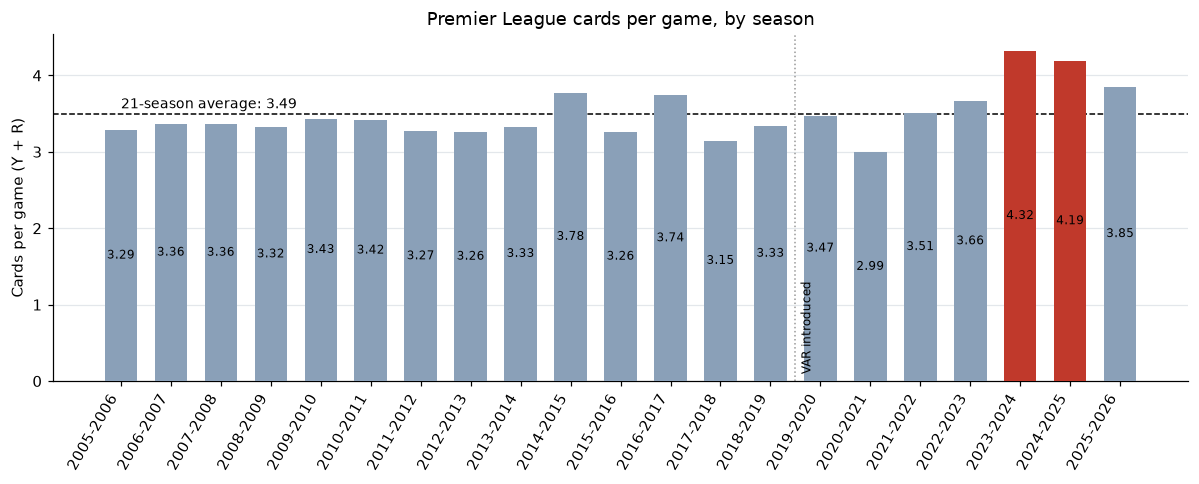

In [78]:
fig, ax = plt.subplots(figsize=(11, 4.5))
colors = [ACCENT if s in ('2023-2024', '2024-2025') else BASE for s in by_season.index]
bars = ax.bar(by_season.index, by_season['avg_cards'], color=colors, width=0.65, zorder=3)
ax.bar_label(bars, fmt='%.2f', label_type='center', fontsize=8, color='black')

ax.axhline(league_avg, color='black', linewidth=1, linestyle='--', zorder=2)
ax.text(0, league_avg + 0.08, f'21-season average: {league_avg:.2f}', fontsize=9)
ax.axvline(by_season.index.get_loc('2019-2020') - 0.5, color='#999', linewidth=1, linestyle=':')
ax.text(by_season.index.get_loc('2019-2020') - 0.4, ax.get_ylim()[1]*0.02, 'VAR introduced',
        fontsize=8, color='black', rotation=90, va='bottom')
ax.set_ylabel('Cards per game (Y + R)')
ax.set_title('Premier League cards per game, by season')
ax.grid(axis='y', color=GRID, zorder=0)
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


2023/24 (4.32 cards/game) and 2024/25 (4.19) are the two highest-carded seasons in the entire 21-season dataset — well clear of the long-run average of 3.49. 2025/26 (3.85, now a complete 380-match season) has cooled slightly but is still the third-highest season on record.

It's tempting to credit VAR, introduced in 2019/20. The data doesn't fully support that story: pre-VAR seasons (2015/16–2018/19) averaged 3.37 cards/game, post-VAR seasons (2019/20–2024/25) averaged 3.69 — a real increase, but a gentle one spread across five seasons. The sharp jump is concentrated almost entirely in the last two years, well after VAR had already settled in. Whatever's driving it (directives on dissent, cynical-foul crackdowns, a more combative style of play), it's recent, not a VAR hangover.

---
## Fact 2 — A third of the 2026/27 referee list has never taken charge of a Premier League match

Before looking at who's strict and who isn't, it's worth knowing that "who's a Premier League referee" changed shape this summer. For 2026/27, the Premier League and EFL Championship moved from the old **Select Group 1 / Select Group 2** split (a PGMO structure) to a single, merged **Professional Referee Group** of 39 officials under a new body, Pro Ref.

That merger pulled in a lot of new names. Matching the 39 confirmed officials against this dataset's 21-season match history shows a league in transition: a small core of veterans has almost all the experience, and over a third of the group has none at all.

In [79]:
experience = (df[df['Referee'].notna()]
                .groupby('Referee').size()
                .reindex([f"{n.split(' ')[0][0]} {n.split(' ')[-1]}" for n in ACTIVE_2026_27], fill_value=0))
experience.index = ACTIVE_2026_27
experience = experience.sort_values(ascending=False)

zero_exp = (experience == 0).sum()
print(f"{(experience > 0).sum()} of the 39 confirmed 2026/27 referees have prior EPL matches in this dataset")
print(f"{zero_exp} have never taken charge of a Premier League match before")
experience.to_frame('career_PL_matches')

26 of the 39 confirmed 2026/27 referees have prior EPL matches in this dataset
13 have never taken charge of a Premier League match before


,career_PL_matches
Michael Oliver,428
Craig Pawson,289
Stuart Attwell,244
Paul Tierney,195
Chris Kavanagh,193
Simon Hooper,140
Andy Madley,133
Peter Bankes,115
Rob Jones,110
Darren England,99


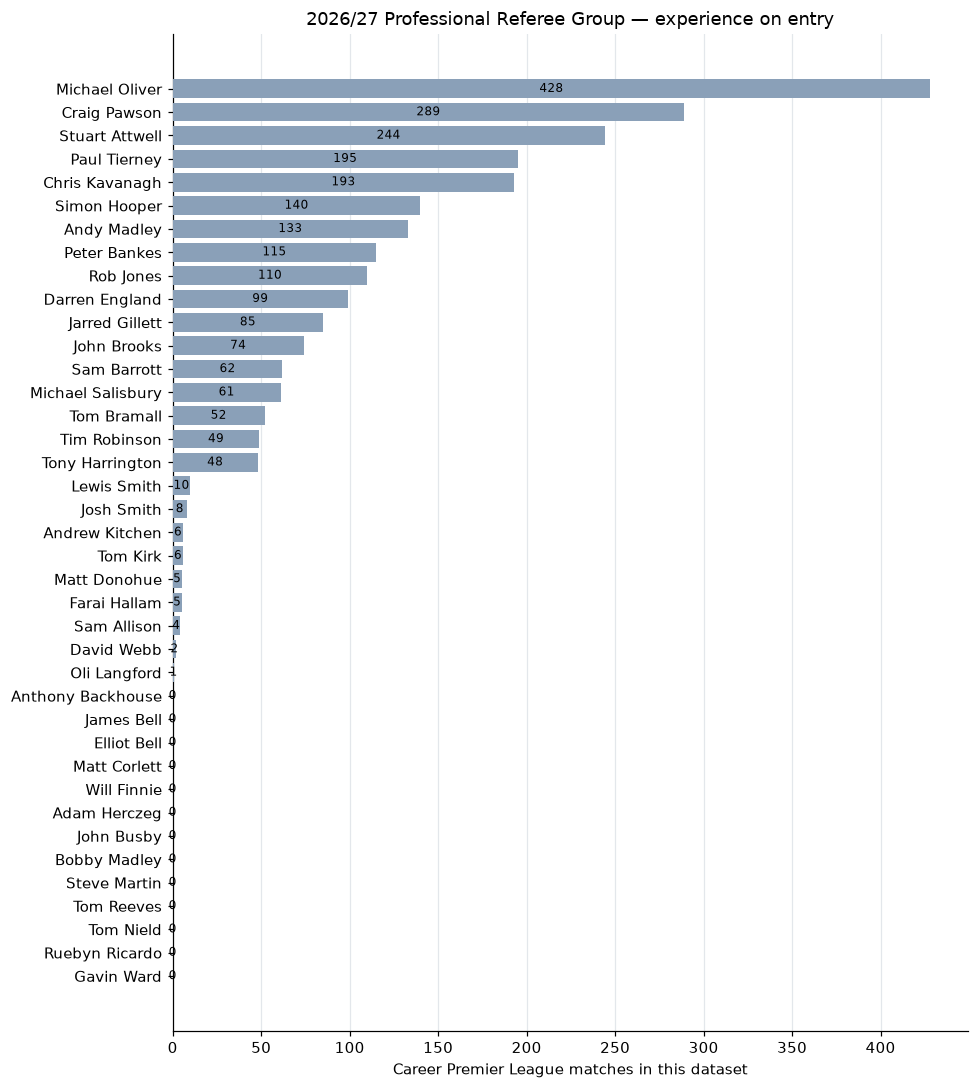

In [80]:
fig, ax = plt.subplots(figsize=(9, 10))
plot_s = experience.iloc[::-1]
colors = ['#c0392b' if v == 0 else BASE for v in plot_s.values]
bars = ax.barh(plot_s.index, plot_s.values, color=colors, zorder=3)
ax.bar_label(bars, fmt='%d', label_type='center', fontsize=8, color='black')

ax.set_xlabel('Career Premier League matches in this dataset')
ax.set_title('2026/27 Professional Referee Group — experience on entry')
ax.grid(axis='x', color=GRID, zorder=0)
plt.tight_layout()
plt.show()


26 of the 39 confirmed 2026/27 referees have prior Premier League matches in this dataset; the other 13 (highlighted in red above) have zero — promoted from the Championship or newly qualified into the top flight. The experience that does exist is still concentrated at the top: Michael Oliver (428 matches), Craig Pawson (289) and Stuart Attwell (244) alone account for roughly 40% of all Premier League experience held across the 39 (961 of 2,424 total career matches). 17 of the 39 clear a 20-match bar in this dataset — that's the group Facts 3, 4 and 7 draw from below.

---
## Fact 3 — John Brooks is, statistically, the strictest referee in the league

Across every referee with 50+ career matches in the dataset, one name comes out on top of average cards per game — and it isn't close.

In [81]:
agg = (df.groupby('Referee')
         .agg(matches=('Referee', 'count'),
              avg_yellows=('total_yellows', 'mean'),
              avg_reds=('total_reds', 'mean'),
              avg_cards=('total_cards', 'mean'),
              avg_fouls=('total_fouls', 'mean'))
         .round(3))
agg['cards_per_foul'] = (agg['avg_cards'] / agg['avg_fouls']).round(4)
qualified = agg[agg['matches'] >= MIN_MATCHES].sort_values('avg_cards', ascending=False)
qualified.head(10)

,matches,avg_yellows,avg_reds,avg_cards,avg_fouls,cards_per_foul
Referee,,,,,,
J Brooks,74,4.324,0.122,4.446,21.770,0.2042
D England,99,3.990,0.111,4.101,21.889,0.1874
T Bramall,52,3.904,0.173,4.077,22.385,0.1821
P Bankes,115,3.939,0.122,4.061,21.643,0.1876
M Riley,102,3.833,0.196,4.029,29.647,0.1359
M Salisbury,61,3.852,0.131,3.984,22.738,0.1752
D Coote,112,3.857,0.116,3.973,23.482,0.1692
R Jones,110,3.864,0.100,3.964,22.573,0.1756
S Barrott,62,3.903,0.048,3.952,20.194,0.1957


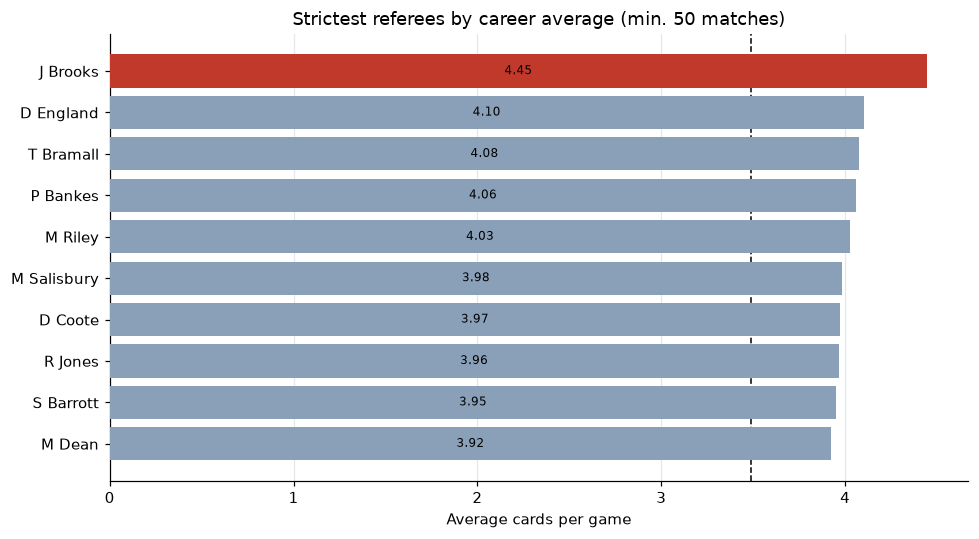

In [82]:
top10 = qualified.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
colors = [ACCENT if r == 'J Brooks' else BASE for r in top10.index]
bars = ax.barh(top10.index, top10['avg_cards'], color=colors, zorder=3)
ax.bar_label(bars, fmt='%.2f', label_type='center', fontsize=8, color='black')
ax.axvline(league_avg, color='black', linewidth=1, linestyle='--', zorder=2)
ax.set_xlabel('Average cards per game')
ax.set_title(f'Strictest referees by career average (min. {MIN_MATCHES} matches)')
ax.grid(axis='x', color=GRID, zorder=0)
plt.tight_layout()
plt.show()


John Brooks averages **4.45 cards per game** across 74 matches — the highest of any referee in the dataset with a qualifying sample, ahead of Darren England (4.10), Tom Bramall (4.08) and Peter Bankes (4.06). It's not an artifact of him overseeing especially foul-heavy matches, either: Brooks also tops the "cards per foul" list at 0.204 (roughly 1 card for every 5 fouls committed in his matches, against a qualified-referee median of 0.16, or closer to 1-in-6). Two independent signals point the same way — Brooks calls cards more readily than his peers, not just more often because his matches are rougher.

Brooks is one of the 39 confirmed 2026/27 Professional Referee Group members, so this isn't a retired-referee footnote — it's live information for the coming season.

---
## Fact 4 — Michael Oliver, the most senior active referee, is the most lenient of the group

Flip the lens from "everyone in the dataset" to "only referees who'll actually take charge of matches in 2026/27," and the most experienced name in that pool sits at the opposite end of the table.

In [83]:
active_agg = (df[df['ref_active_2026_27']]
                .groupby('Referee')
                .agg(matches=('Referee', 'count'),
                     avg_yellows=('total_yellows', 'mean'),
                     avg_reds=('total_reds', 'mean'),
                     avg_cards=('total_cards', 'mean'))
                .round(3))
active_qualified = active_agg[active_agg['matches'] >= 20].sort_values('avg_cards', ascending=False)
print(f"{len(active_qualified)} of the 39 confirmed 2026/27 referees clear the 20-match bar")
active_qualified

17 of the 39 confirmed 2026/27 referees clear the 20-match bar


,matches,avg_yellows,avg_reds,avg_cards
Referee,,,,
J Brooks,74,4.324,0.122,4.446
T Robinson,49,4.163,0.061,4.224
D England,99,3.990,0.111,4.101
T Bramall,52,3.904,0.173,4.077
P Bankes,115,3.939,0.122,4.061
M Salisbury,61,3.852,0.131,3.984
R Jones,110,3.864,0.100,3.964
S Barrott,62,3.903,0.048,3.952
S Attwell,244,3.705,0.131,3.836


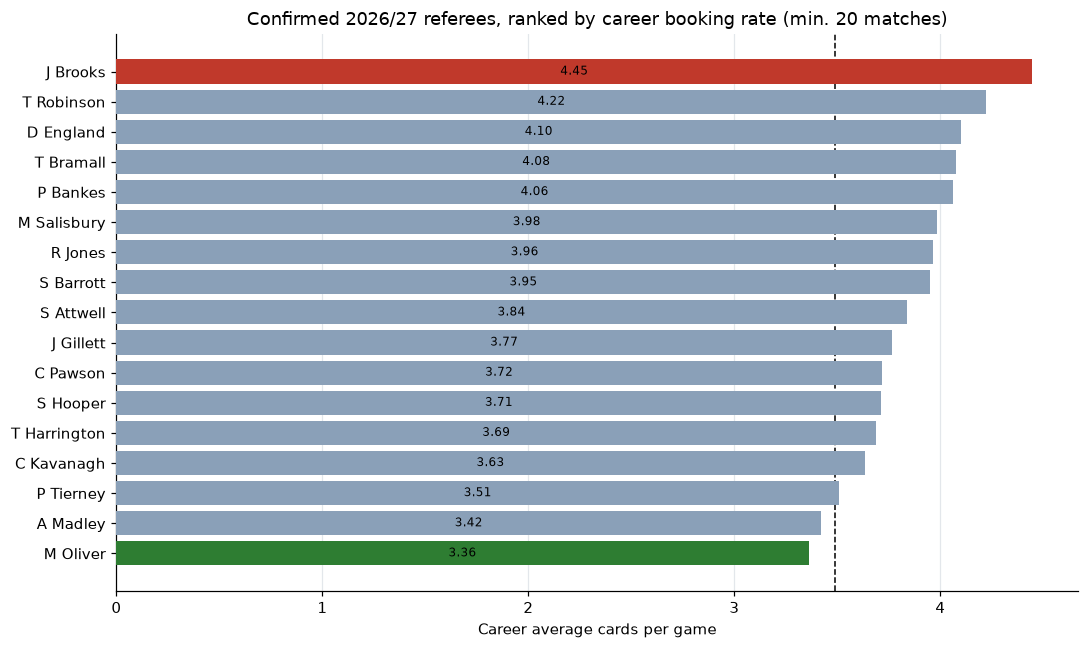

In [84]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_df = active_qualified.iloc[::-1]
colors = [ACCENT if r == 'J Brooks' else ('#2e7d32' if r == 'M Oliver' else BASE) for r in plot_df.index]
bars = ax.barh(plot_df.index, plot_df['avg_cards'], color=colors, zorder=3)
ax.bar_label(bars, fmt='%.2f', label_type='center', fontsize=8, color='black')

ax.axvline(league_avg, color='black', linewidth=1, linestyle='--', zorder=2)
ax.set_xlabel('Career average cards per game')
ax.set_title('Confirmed 2026/27 referees, ranked by career booking rate (min. 20 matches)')
ax.grid(axis='x', color=GRID, zorder=0)
plt.tight_layout()
plt.show()


In [85]:
oliver = active_qualified.loc['M Oliver']
print(f"M Oliver: {int(oliver['matches'])} career matches, {oliver['avg_cards']:.2f} cards/game "
      f"— lowest of the {len(active_qualified)} qualified active referees")

M Oliver: 428 career matches, 3.36 cards/game — lowest of the 17 qualified active referees


Michael Oliver has the largest sample of any active referee (428 matches — nearly 50% more than the next-most-experienced name in the qualifying group, Craig Pawson at 289) and the *lowest* average cards per game of the 17, at 3.36 — noticeably below the 3.49 league-wide average, despite typically being handed the season's highest-profile fixtures. Whether that's a calmer whistle, matches between better-disciplined teams, or simply what the biggest games look like tactically, the most trusted name in English officiating is, by the numbers, one of the last referees you'd point to as a "cards" official.

---
## Fact 5 — Away teams get booked more than home teams, almost universally

This one isn't about any single referee — it's close to a league-wide constant. For 38 of the 41 qualified referees, the away side picks up more yellow cards per game than the home side.

In [86]:
home_away = (df.groupby('Referee')
               .agg(matches=('Referee', 'count'),
                    home_yellows=('HY', 'mean'),
                    away_yellows=('AY', 'mean'))
               )
home_away['away_home_ratio'] = (home_away['away_yellows'] / home_away['home_yellows']).round(3)
ha_qualified = home_away[home_away['matches'] >= MIN_MATCHES].sort_values('away_home_ratio', ascending=False)

above_parity = (ha_qualified['away_home_ratio'] > 1).sum()
at_parity = (ha_qualified['away_home_ratio'] == 1).sum()
print(f"{above_parity} of {len(ha_qualified)} qualified referees book the away side more than the home side")
print(f"{at_parity} sit at exact parity; {len(ha_qualified) - above_parity - at_parity} invert it")
print(f"League-wide: {df['HY'].mean():.2f} home yellows/game vs {df['AY'].mean():.2f} away yellows/game")
ha_qualified[['matches', 'home_yellows', 'away_yellows', 'away_home_ratio']].head(5)

38 of 41 qualified referees book the away side more than the home side
2 sit at exact parity; 1 invert it
League-wide: 1.52 home yellows/game vs 1.83 away yellows/game


,matches,home_yellows,away_yellows,away_home_ratio
Referee,,,,
S Bennett,139,1.395683,2.100719,1.505
P Dowd,250,1.436000,2.156000,1.501
M Halsey,159,0.830189,1.207547,1.455
G Poll,61,1.360656,1.967213,1.446
R Jones,110,1.618182,2.245455,1.388


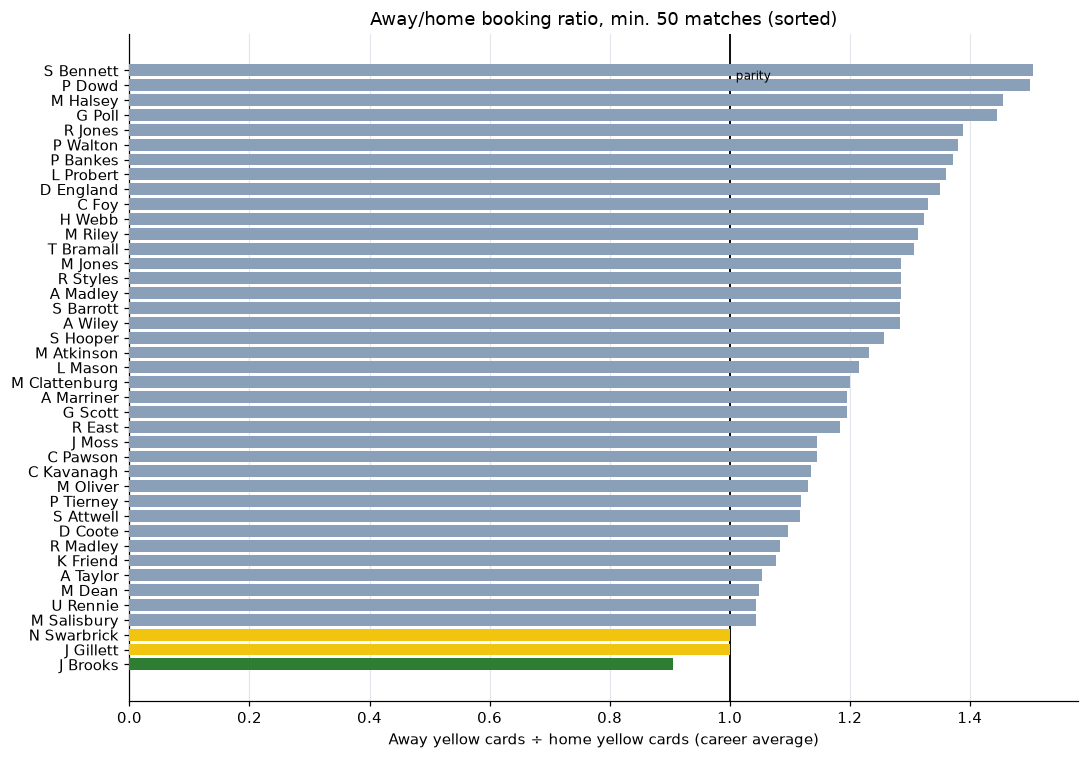

In [87]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_df = ha_qualified.sort_values('away_home_ratio')
colors = ['#2e7d32' if v < 1 else ('#f1c40f' if v == 1 else BASE) for v in plot_df['away_home_ratio']]
ax.barh(plot_df.index, plot_df['away_home_ratio'], color=colors, zorder=3)
ax.axvline(1.0, color='black', linewidth=1.2, zorder=2)
ax.text(1.01, len(plot_df) - 1, 'parity', fontsize=8, va='top')
ax.set_xlabel('Away yellow cards ÷ home yellow cards (career average)')
ax.set_title(f'Away/home booking ratio, min. {MIN_MATCHES} matches (sorted)')
ax.grid(axis='x', color=GRID, zorder=0)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

League-wide, away teams average 1.82 yellows per game against 1.52 for home teams — roughly 20% more cards for the visitors. Among referees with a large enough sample, the pattern holds for 38 of 41. Only three don't strictly follow it: John Brooks actually books home teams *more* (2.27 vs 2.05), while Jarred Gillett and Neil Swarbrick both land at exact parity (1.86 vs 1.86, and 1.67 vs 1.67, respectively). Whether the general pattern reflects genuine home advantage shaping which team commits more cynical fouls, crowd effect on the official, or home teams simply seeing more of the ball while away teams do more defensive tackling, it's about as close to a universal referee tendency as this dataset shows.

---
## Fact 6 — A strict referee doesn't obviously tilt the scoreline

Given Fact 3 and Fact 5, a natural next question: do stricter referees also produce more lopsided results — say, by protecting home teams more (or less)? The data says no, not in any way worth betting on.

In [88]:
corr_df = qualified.join(ha_qualified[['away_home_ratio']])
corr = corr_df['avg_cards'].corr(corr_df['away_home_ratio'])

home_win = (df.groupby('Referee')
              .agg(matches=('Referee', 'count'), home_win_rate=('home_win', 'mean'))
              )
hw_qualified = home_win[home_win['matches'] >= MIN_MATCHES]

stats_table = pd.DataFrame({
    'metric': ['Correlation: cards/game vs. away/home ratio',
               'League-wide home win rate',
               'Home win rate range (qualified referees)',
               'Home win rate std. dev (qualified referees)'],
    'value': [f'{corr:.2f}', f"{df['home_win'].mean():.1%}",
              f"{hw_qualified['home_win_rate'].min():.1%} – {hw_qualified['home_win_rate'].max():.1%}",
              f"{hw_qualified['home_win_rate'].std():.1%}"],
})
stats_table

,metric,value
0,Correlation: cards/game vs. away/home ratio,-0.22
1,League-wide home win rate,45.6%
2,Home win rate range (qualified referees),34.1% – 53.9%
3,Home win rate std. dev (qualified referees),3.8%


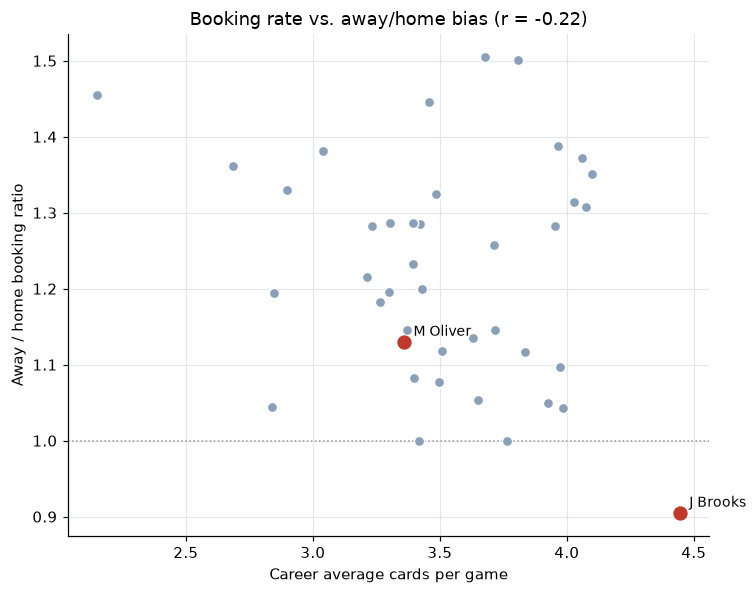

In [99]:
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(corr_df['avg_cards'], corr_df['away_home_ratio'], color=BASE, s=45, zorder=3, edgecolor='white')
for name in ['J Brooks', 'M Oliver']:
    row = corr_df.loc[name]
    ax.scatter(row['avg_cards'], row['away_home_ratio'], color=ACCENT, s=70, zorder=4)
    ax.annotate(name, (row['avg_cards'], row['away_home_ratio']), textcoords='offset points',
                xytext=(6, 4), fontsize=9)
ax.axhline(1.0, color='#999', linewidth=1, linestyle=':', zorder=2)
ax.set_xlabel('Career average cards per game')
ax.set_ylabel('Away / home booking ratio')
ax.set_title(f'Booking rate vs. away/home bias (r = {corr:.2f})')
ax.grid(color=GRID, zorder=0)
plt.tight_layout()
plt.show()

The correlation between how many cards a referee gives out and how lopsided their home/away booking split is comes out at **-0.22** — weak, and in the opposite direction you might expect (stricter referees skew *slightly* less home-biased, not more). Home win rates do vary by referee (34.1% to 53.9% across the qualified group, against a 45.6% league average), but that spread is much more plausibly explained by which teams and fixtures each referee happens to be assigned — the data can't separate "this referee favors home teams" from "this referee gets a disproportionate share of Big Six home fixtures" — than by anything about their card-giving style. Worth knowing mainly as a caution against the intuitive "strict ref = home advantage" story: this dataset doesn't back it up.

---
## Fact 7 — The most-carding referee and the most-sending-off referee are different people

Cards and red cards don't rank the same way. Someone can be at the top of the yellow-card table and mid-pack for reds, or the reverse — and the referee who hands out the *fewest* cards overall is, surprisingly, nowhere near the calmest on reds specifically.

In [90]:
active_reds = active_qualified.sort_values('avg_reds', ascending=False)
active_reds[['matches', 'avg_yellows', 'avg_reds', 'avg_cards']]

,matches,avg_yellows,avg_reds,avg_cards
Referee,,,,
T Bramall,52,3.904,0.173,4.077
C Pawson,289,3.578,0.138,3.716
M Oliver,428,3.224,0.136,3.360
S Attwell,244,3.705,0.131,3.836
M Salisbury,61,3.852,0.131,3.984
J Brooks,74,4.324,0.122,4.446
P Bankes,115,3.939,0.122,4.061
C Kavanagh,193,3.518,0.114,3.632
D England,99,3.990,0.111,4.101


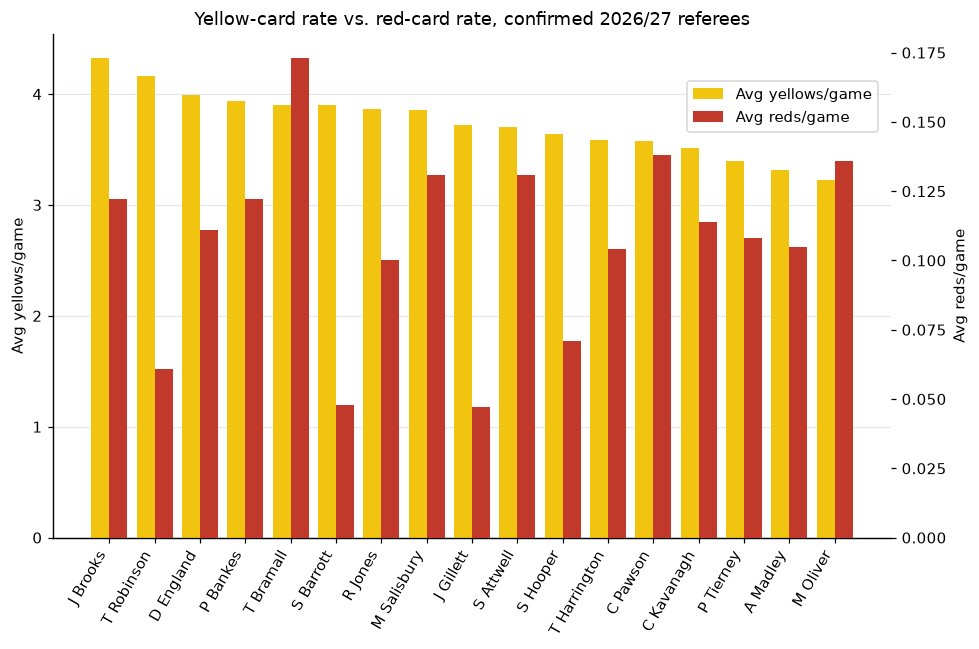

In [98]:
fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(active_qualified))
order = active_qualified.sort_values('avg_yellows', ascending=False)
bars1 = ax.bar(x - 0.2, order['avg_yellows'], width=0.4, label='Avg yellows/game', color='#f1c40f', zorder=3)

ax2 = ax.twinx()
bars2 = ax2.bar(x + 0.2, order['avg_reds'], width=0.4, label='Avg reds/game', color=ACCENT, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(order.index, rotation=60, ha='right')
ax.set_ylabel('Avg yellows/game')
ax2.set_ylabel('Avg reds/game')
ax.set_title('Yellow-card rate vs. red-card rate, confirmed 2026/27 referees')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88))
ax.grid(axis='y', color=GRID, zorder=0)
plt.tight_layout()
plt.show()


Tom Bramall leads the confirmed 2026/27 group in red cards (0.173/game — roughly one every 5-6 matches) despite sitting well up the pack for yellows too (5th among the 17, so he's not purely a "reds specialist" — just strict across the board). The sharper twist is at the other end: Michael Oliver, the most lenient referee in the group on overall cards (Fact 4), is only the *3rd*-highest for red cards (0.136/game) — well above John Brooks, who tops yellows by a wide margin but ranks just 7th for reds (0.122). A "cards" number for a referee is really two different numbers pretending to be one.

---
## Fact 8 — Heading into 2026/27: last season's form guide

The closest thing to a "current form" number for a referee is how they called games in the season just gone — now a complete 380-match 2025/26 season in this dataset.

In [92]:
MIN_CURRENT = 8  # cuts the noisiest single-digit-appearance referees from the ranking

current = df[df['season_id'] == '2025-2026']
current_agg = (current.groupby('Referee')
                 .agg(matches=('Referee', 'count'),
                      avg_yellows=('total_yellows', 'mean'),
                      avg_reds=('total_reds', 'mean'),
                      avg_cards=('total_cards', 'mean'))
                 .round(3))
current_qualified = current_agg[current_agg['matches'] >= MIN_CURRENT].sort_values('avg_cards', ascending=False)

print(f"{current['Referee'].nunique()} referees appear in the {len(current)} matches of the 2025/26 season")
print(f"2025/26 league-wide average: {current['total_cards'].mean():.2f} cards/game "
      f"(21-season average: {league_avg:.2f})")
current_qualified

23 referees appear in the 380 matches of the 2025/26 season
2025/26 league-wide average: 3.85 cards/game (21-season average: 3.49)


,matches,avg_yellows,avg_reds,avg_cards
Referee,,,,
S Attwell,25,4.600,0.080,4.680
D England,23,4.304,0.130,4.435
M Salisbury,14,4.357,0.000,4.357
R Jones,18,4.167,0.000,4.167
T Bramall,22,4.045,0.091,4.136
S Hooper,15,4.000,0.133,4.133
T Robinson,9,4.000,0.111,4.111
C Kavanagh,30,3.967,0.100,4.067
P Bankes,22,3.818,0.182,4.000


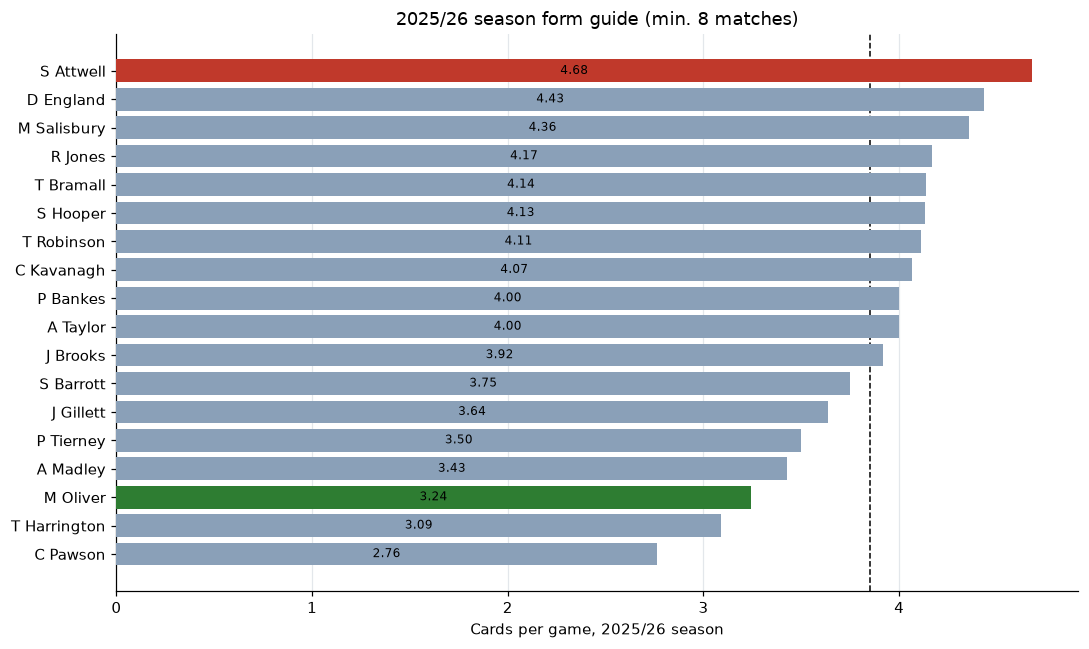

In [94]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_df = current_qualified.sort_values('avg_cards')
colors = [ACCENT if r == 'S Attwell' else ('#2e7d32' if r == 'M Oliver' else BASE) for r in plot_df.index]
bars = ax.barh(plot_df.index, plot_df['avg_cards'], color=colors, zorder=3)
ax.bar_label(bars, fmt='%.2f', label_type='center', fontsize=8, color='black')
ax.axvline(current['total_cards'].mean(), color='black', linewidth=1, linestyle='--', zorder=2)
ax.set_xlabel('Cards per game, 2025/26 season')
ax.set_title(f'2025/26 season form guide (min. {MIN_CURRENT} matches)')
ax.grid(axis='x', color=GRID, zorder=0)
plt.tight_layout()
plt.show()


Stuart Attwell ran the hottest whistle of the full 2025/26 season (4.68 cards/game across 25 matches), with Darren England (4.44, 23 matches) and Michael Salisbury (4.36, though only 14 matches) close behind. Michael Oliver, true to his career pattern in Fact 4, was again near the calm end — 3.24 cards/game across a solid 29-match sample, second only to Craig Pawson (2.76, 21 matches) as the season's most restrained regular. John Brooks took charge of just 12 matches in 2025/26, too few to be conclusive on its own, but his 3.92 cards/game is still comfortably above the league average and consistent with his career reputation from Fact 3.

None of this is destiny for 2026/27 — squads change, directives from the league change, and even a 20-plus-match sample is small in the grand scheme. But if the fixture list for next weekend tells you Stuart Attwell or Darren England has the whistle, the base rate says: expect cards. If it says Michael Oliver or Craig Pawson, expect a calmer afternoon.

---
## Recap

1. **Cards are at a 21-season high.** 2023/24 and 2024/25 are the two most-carded seasons in the dataset, and the jump is concentrated in the last two years — not a gradual VAR-era drift.
2. **A third of the 2026/27 referee list is unproven at this level.** 13 of the 39 confirmed officials have zero Premier League matches in the historical record; three veterans (Oliver, Pawson, Attwell) account for roughly 40% of the group's total experience.
3. **John Brooks is the strictest active referee**, by career average and by cards-per-foul.
4. **Michael Oliver, the most experienced active referee, is the most lenient** of the confirmed 2026/27 group — on overall cards.
5. **Away teams get booked more than home teams** for 38 of 41 qualified referees — close to a league constant.
6. **Booking strictness doesn't predict who a referee favors** — the link between cards/game and home/away bias is weak (r = -0.22).
7. **Yellow-card rate and red-card rate rank differently** — Michael Oliver is the most lenient on overall cards but 3rd for reds; Tom Bramall leads reds despite ranking 5th, not 1st, on yellows.
8. **Last season's form guide**: Stuart Attwell and Darren England ran hottest in 2025/26; Michael Oliver and Craig Pawson ran coolest — consistent with their career numbers.

**What's next in this series**: Game Week 1 predictions for 2026/27, once the team-name canonicalization work in the main pipeline is done (10 of 20 clubs currently mismatch between the fixture list and the model's encoders).
